In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
#Photon energy set to 2.41eV and electron beam set to 7GeV, code for generating a dataframe
cols = [
    "ph_px", "ph_py", "ph_pz", "ph_E",
    "xsec_unpol", "xsec_pol",
    "xsec_alpha_unpol", "xsec_alpha_pol",
    "el_px", "el_py", "el_pz", "el_E"
]

data = []
with open("comrad_output_test.txt", "r") as f:
    for i, line in enumerate(f, 1):
        parts = line.strip().split()

        # Convert to float, ignoring lines that cannot be converted
        try:
            nums = [float(x) for x in parts]
        except ValueError:
            continue  # ignore text lines that cannot be converted to float

        # Only append lines with exactly 12 columns
        if len(nums) == 12:
            data.append(nums)
        else:
            print(f"line {i}: has {len(nums)} columns, expected 12. Skipping this line.")


df = pd.DataFrame(data, columns=cols)

line 1000004: has 0 columns, expected 12. Skipping this line.


In [22]:
df.head()

,ph_px,ph_py,ph_pz,ph_E,xsec_unpol,xsec_pol,xsec_alpha_unpol,xsec_alpha_pol,el_px,el_py,el_pz,el_E
0,-0.000044,-0.000040,0.760345,0.760345,0.000403,-0.000005,1.925758e-08,3.939732e-08,0.000044,0.000040,6.239655,6.239655
1,0.000021,-0.000015,0.072542,0.072542,0.000731,-0.000008,1.795791e-07,1.199800e-08,-0.000021,0.000015,6.927458,6.927458
2,-0.000055,0.000015,0.907376,0.907376,0.000413,0.000017,-2.146497e-09,8.271987e-08,0.000055,-0.000015,6.092624,6.092624
3,0.000056,0.000004,0.937601,0.937601,0.000420,0.000023,-6.587220e-09,9.344846e-08,-0.000056,-0.000004,6.062399,6.062399
4,-0.000027,-0.000022,0.139146,0.139146,0.000678,-0.000013,1.564563e-07,3.091620e-09,0.000027,0.000022,6.860854,6.860854


In [23]:
#Extracting the electron momentum components and energy from the dataframe
el_px=np.array(df["el_px"])
el_py=np.array(df["el_py"])
el_pz=np.array(df["el_pz"])
el_E=np.array(df["el_E"])

#Calculating the total unpolarized cross-section and the weights for each event
Total_x_section=np.array(df["xsec_unpol"]).sum()
Total_x_section
weights=np.array(df["xsec_unpol"])/Total_x_section

In [24]:
#Function to calculate the binned mean and standard deviation of analyzing power values based 
def binned_mean_std(energy, asymmetry, bins=50):
    energy = np.asarray(energy)
    asymmetry = np.asarray(asymmetry)
    # Delete any NaN or infinite values from the arrays
    valid = np.isfinite(energy) & np.isfinite(asymmetry)
    energy = energy[valid]
    asymmetry = asymmetry[valid]

    edges = np.linspace(energy.min(), energy.max(), bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    mean_A = np.full(bins, np.nan)
    std_A = np.full(bins, np.nan)
    counts = np.zeros(bins, dtype=int)

    bin_index = np.digitize(energy, edges) - 1

    # Include correctly the points at the right edge
    #bin_index[energy == edges[-1]] = bins - 1

    for i in range(bins):
        values = asymmetry[bin_index == i]
        counts[i] = len(values)

        if len(values) >= 2:
            mean_A[i] = np.mean(values)
            std_A[i] = np.std(values, ddof=1)

    valid_bins = np.isfinite(mean_A)

    return (
        centers[valid_bins],
        mean_A[valid_bins],
        std_A[valid_bins],
        counts[valid_bins]
    )

In [25]:
A_0=np.array(df["xsec_pol"])/np.array(df["xsec_unpol"])
E, A_mean, A_std, N = binned_mean_std(
    el_E, A_0, bins=50)

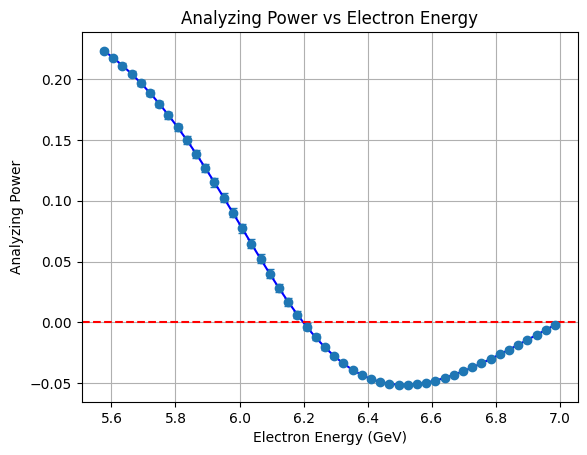

In [31]:
plt.errorbar(E, A_mean, yerr=A_std,capsize=3, fmt='o', label='Binned Analyzing Power')
plt.plot(E, A_mean, label='Mean Analyzing Power', color='blue')
plt.xlabel('Electron Energy (GeV)')
plt.ylabel('Analyzing Power')
plt.grid()
plt.axhline(0, color='red', linestyle='--', label='Zero Analyzing Power')
plt.title('Analyzing Power vs Electron Energy')
plt.savefig('analyzing_power_vs_energy.png')

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
C:\Users\dsant\AppData\Local\Temp\ipykernel_38156\3483519697.py:4: SyntaxWarning: invalid escape sequence '\%'
  plt.title('Histogram of $100\%$ right polarized Electron Energy Distribution')


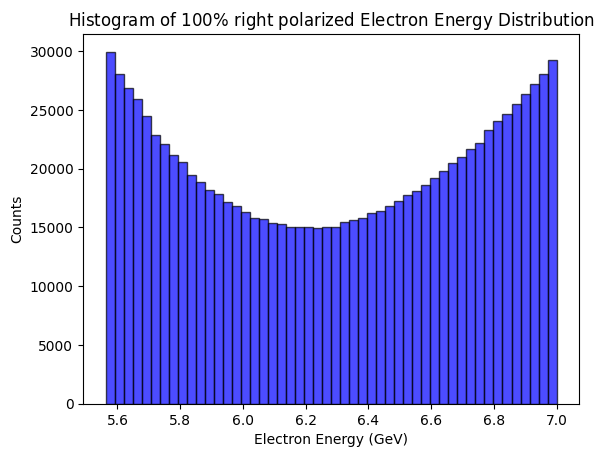

In [30]:
plt.hist(el_E, bins=50, weights=weights*10**6, alpha=0.7, color='blue', label='Electron Energy Distribution with right polarization', edgecolor="black")
plt.xlabel('Electron Energy (GeV)')
plt.ylabel('Counts')
plt.title('Histogram of $100\%$ right polarized Electron Energy Distribution')
plt.savefig('electron_energy_distribution.png')